NORMALITY (Shapiro-Wilk)

	Shapiro-Wilk normality test

data:  residuals(lm_model)
W = 0.98248, p-value = 0.02329


HOMOGENEITY OF VARIANCE (Bartlett's Test)

	Bartlett test of homogeneity of variances

data:  Rating by interaction(Gender, Looks, Personality)
Bartlett's K-squared = 20.233, df = 17, p-value = 0.2625


3-WAY MIXED ANOVA RESULTS

Error: ID
          Df Sum Sq Mean Sq F value Pr(>F)
Gender     1    0.2    0.20   0.005  0.946
Residuals 18  760.2   42.23               

Error: ID:Looks
             Df Sum Sq Mean Sq F value   Pr(>F)    
Looks         2  20780   10390  423.73  < 2e-16 ***
Gender:Looks  2   3944    1972   80.43 5.23e-14 ***
Residuals    36    883      25                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Error: ID:Personality
                   Df Sum Sq Mean Sq F value   Pr(>F)    
Personality         2  23234   11617  328.25  < 2e-16 ***
Gender:Personality  2   4420    2210   62.45 1.97e-12 ***
Residuals          36   12

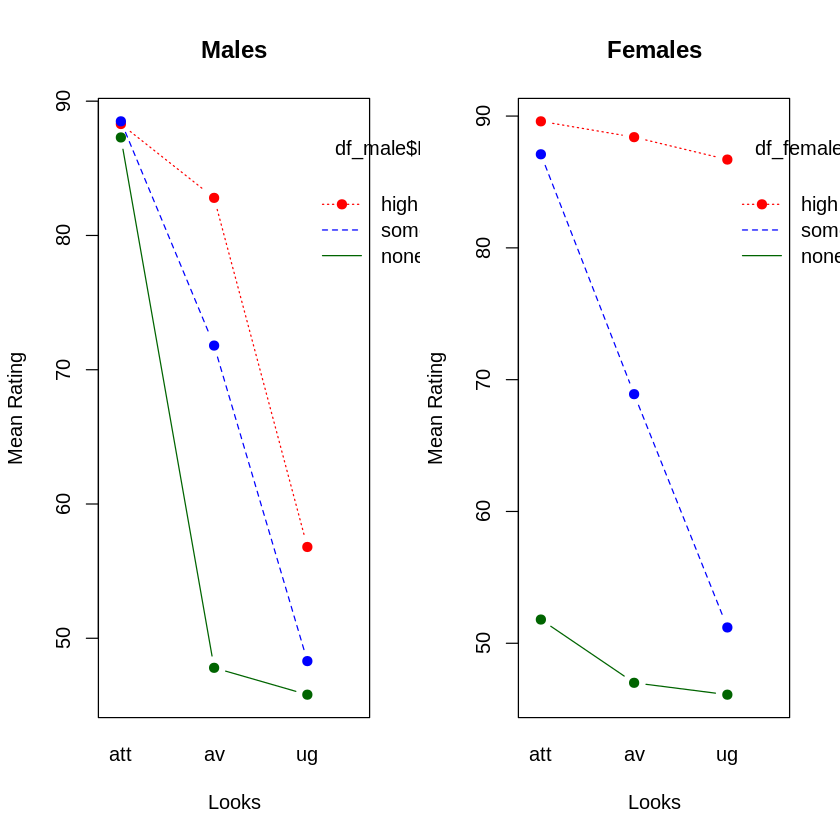

In [4]:
speed_dating <- data.frame(
  Gender = factor(rep(c("Male", "Female"), each = 10)),
  att_high = c(86,91,89,89,80,80,89,100,90,89, 89,84,99,86,89,80,82,97,95,95),
  av_high  = c(84,83,88,69,81,84,85,94,74,86,  91,90,100,89,87,81,92,69,92,93),
  ug_high  = c(67,53,48,58,57,51,61,56,54,63,  93,85,89,83,80,79,85,87,90,96),
  att_some = c(88,83,99,86,88,96,87,86,92,80,  88,95,80,86,83,86,81,95,98,79),
  av_some  = c(69,74,70,77,71,63,79,71,71,73,  65,70,79,74,74,59,66,72,64,66),
  ug_some  = c(50,48,48,40,50,42,44,54,58,49,  54,60,53,58,43,47,47,51,53,46),
  att_none = c(97,86,90,87,82,92,86,84,78,91,  55,50,51,52,58,51,50,45,54,52),
  av_none  = c(48,50,45,47,50,48,50,54,38,48,  48,44,48,48,50,47,45,48,53,39),
  ug_none  = c(47,46,48,53,45,43,45,47,45,39,  52,45,44,47,48,40,47,46,45,47)
)
speed_dating$ID <- factor(1:nrow(speed_dating))

varying_cols <- c("att_high", "av_high", "ug_high",
                  "att_some", "av_some", "ug_some",
                  "att_none", "av_none", "ug_none")

df_long <- reshape(speed_dating, varying = varying_cols, v.names = "Rating", timevar = "Condition", times = varying_cols, idvar = "ID", direction = "long")
df_long$Looks <- factor(sapply(strsplit(as.character(df_long$Condition), "_"), `[`, 1), levels=c("att", "av", "ug"))
df_long$Personality <- factor(sapply(strsplit(as.character(df_long$Condition), "_"), `[`, 2), levels=c("high", "some", "none"))

cat("NORMALITY (Shapiro-Wilk)\n")
lm_model <- lm(Rating ~ Gender * Looks * Personality, data = df_long)
print(shapiro.test(residuals(lm_model)))

cat("\nHOMOGENEITY OF VARIANCE (Bartlett's Test)\n")
print(bartlett.test(Rating ~ interaction(Gender, Looks, Personality), data = df_long))

cat("\n3-WAY MIXED ANOVA RESULTS\n")
res_aov <- aov(Rating ~ Gender * Looks * Personality + Error(ID/(Looks*Personality)), data = df_long)
print(summary(res_aov))

cat("\nSIMPLE 2-WAY INTERACTIONS (By Gender)\n")
df_male <- subset(df_long, Gender == "Male")
df_female <- subset(df_long, Gender == "Female")

cat("\nMALES Only\n")
aov_male <- aov(Rating ~ Looks * Personality + Error(ID/(Looks*Personality)), data = df_male)
print(summary(aov_male))

cat("\nFEMALES Only\n")
aov_female <- aov(Rating ~ Looks * Personality + Error(ID/(Looks*Personality)), data = df_female)
print(summary(aov_female))

par(mfrow=c(1,2))
interaction.plot(x.factor = df_male$Looks, trace.factor = df_male$Personality, response = df_male$Rating, type = "b", main = "Males", xlab = "Looks", ylab = "Mean Rating", col = c("red", "blue", "darkgreen"), pch = 19, legend = TRUE)
interaction.plot(x.factor = df_female$Looks, trace.factor = df_female$Personality, response = df_female$Rating, type = "b", main = "Females", xlab = "Looks", ylab = "Mean Rating", col = c("red", "blue", "darkgreen"), pch = 19, legend = TRUE)
par(mfrow=c(1,1))

**Dataset and Problem**
A study was conducted to determine how physical attractiveness, personality, and gender influence speed-dating preferences. A 2 x 3 x 3 mixed-design ANOVA was utilized. The between-subjects variable was Gender. The two within-subjects variables were Looks (Attractive, Average, Ugly) and Personality (High Charisma, Some Charisma, No Charisma).

**Checking of Assumptions**
Prior to analysis, the assumptions of the mixed ANOVA were evaluated. The data were assessed for normality using the Shapiro-Wilk test; while there was a minor deviation from normality ($p = .023$), ANOVA is generally robust to these violations. Homogeneity of variances was met as assessed by Bartlett's test ($p = .263$).

**Main Effects and Three-Way Interaction**
The mixed-design ANOVA revealed a statistically significant three-way interaction between Gender, Looks, and Personality, $F(4, 72) = 24.12$, $p < .001$. Because the three-way interaction was significant, the simple two-way interactions at each level of Gender were analyzed.

**Simple Two-Way Interactions and Interpretation**
Males: There was a significant two-way interaction between Looks and Personality for males, $F(4, 36) = 26.87$, $p < .001$. For males, physical attractiveness overwhelmingly drove dating ratings. Attractive partners were rated extremely high regardless of their personality. Personality only mattered when the partner's looks were average or ugly.
Females: There was also a significant two-way interaction between Looks and Personality for females, $F(4, 36) = 34.91$, $p < .001$. Conversely to males, females heavily prioritized personality. Highly charismatic partners were rated exceptionally high regardless of their physical attractiveness, and females heavily penalized attractive partners if they possessed no charisma.